In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
import joblib


In [16]:
file = "../Vascular epiphyte global distributions/database.xlsx"
region_climate = pd.read_excel(file, sheet_name=4)
epi_richness = pd.read_excel(file, sheet_name=3)


In [17]:
region_climate = region_climate[
	[
		'link_ID',
		'biome',
		'kingdom_WWF',
		'prec',
		'PrecSeas',
		'temp_mean',
		'ElevRange'
	]
]
epi_richness = epi_richness[
	[
		'link_ID',
		'epi_total',
		'epi_ferns',
		'epi_seeds'
	]
]
epi_region = pd.merge(
    region_climate,
    epi_richness,
    on="link_ID",
    how="inner"
)

In [18]:
epi_region["epi_score"] = (
    epi_region["epi_total"].rank(pct=True)
)

epi_region["fern_score"] = (
    epi_region["epi_ferns"].rank(pct=True)
)

epi_region["seed_score"] = (
    epi_region["epi_seeds"].rank(pct=True)
)

In [19]:
X = epi_region[
    [
        "biome",
        "prec",
        "PrecSeas",
        "temp_mean",
        "ElevRange"
    ]
]

categorical = ["biome"]

numeric = [
    "prec",
    "PrecSeas",
    "temp_mean",
    "ElevRange"
]

y = epi_region["epi_score"]

In [20]:
preprocessor = ColumnTransformer(
    [
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical
        ),
        (
            "num",
            "passthrough",
            numeric
        )
    ]
)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

model.fit(X_train, y_train)

,steps,"[('prep', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

cv_pred = cross_val_predict(
    model,
    X,
    y,
    cv=5
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("Mean R²:", scores.mean())
print("Std:", scores.std())

Mean R²: 0.8168177588371003
Std: 0.046995370621834086


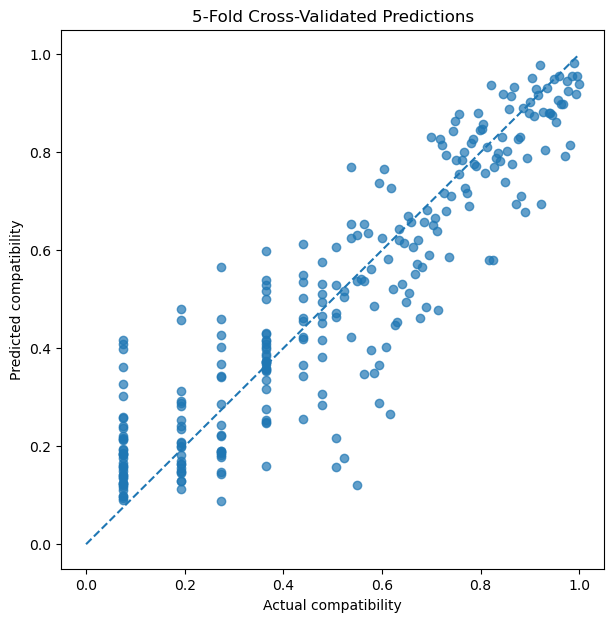

In [24]:
plt.figure(figsize=(7,7))

plt.scatter(
    y,
    cv_pred,
    alpha=0.7
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Actual compatibility")
plt.ylabel("Predicted compatibility")
plt.title("5-Fold Cross-Validated Predictions")

plt.show()

In [25]:
rf = model.named_steps["rf"]

feature_names = (
    model.named_steps["prep"]
         .get_feature_names_out()
)

importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
12,num__prec,0.652386
14,num__temp_mean,0.202123
13,num__PrecSeas,0.057198
15,num__ElevRange,0.036910
9,"cat__biome_Tropical & Subtropical Grasslands, ...",0.023084
10,cat__biome_Tropical & Subtropical Moist Broadl...,0.013952
3,cat__biome_Montane Grasslands & Shrublands,0.003712
1,cat__biome_Deserts & Xeric Shrublands,0.001907
4,cat__biome_Temperate Broadleaf & Mixed Forests,0.001861
2,"cat__biome_Mediterranean Forests, Woodlands & ...",0.001850


In [29]:
model.fit(X, y)
joblib.dump(model, "../epiphyte_suitability.pkl")

['../epiphyte_suitability.pkl']